In [2]:
using Oceananigans
using JLD2
using CairoMakie
using CairoMakie.Colors
using Statistics

include("../src-fig/figures/preinitial_conditions.jl")
include("../src-simulation/parameters.jl")
include("../src-simulation/base_state.jl")
include("../src-simulation/grid_faces.jl")

include("../src-fig/plotting.jl")



[ Info: Oceananigans will use 4 threads


θτ_from_str (generic function with 1 method)

In [34]:

foldernames = map(run_ids) do run_id
    joinpath("../../scratch/turbulence-at-many-fronts", run_id)
end
DFMs = map(foldernames) do foldername
    joinpath(foldername, "DFM.jld2")
end
TKEs = map(foldernames) do foldername
    joinpath(foldername, "TKE.jld2")
end
TKELs = map(foldernames) do foldername
    joinpath(foldername, "TKE-L.jld2")
end

5-element Vector{String}:
 "../../scratch/turbulence-at-many-fronts/0_14-init-0_01-0_0-C/TKE-L.jld2"
 "../../scratch/turbulence-at-many-fronts/0_14-init-0_03-0_0-C/TKE-L.jld2"
 "../../scratch/turbulence-at-many-fronts/0_14-init-0_05-0_0-C/TKE-L.jld2"
 "../../scratch/turbulence-at-many-fronts/0_14-init-0_1-0_0-C/TKE-L.jld2"
 "../../scratch/turbulence-at-many-fronts/0_14-init-0_2-0_0-C/TKE-L.jld2"

In [35]:
# Final buoyancy
bs = map(foldernames) do foldername
    DFM = joinpath(foldername, "DFM.jld2")
    iterations, times = iterations_times(DFM)
    get_field(DFM, "b_dfm", iterations[end])
end

# Center
bs_center = map(foldernames) do foldername
    DFM = joinpath(foldername, "DFM.jld2")
    iterations, times = iterations_times(DFM)
    sp = simulation_parameters(DFM)
    inds = center_indices(DFM)
    @inline center_avg(field) = mean(field; dims=2)[:, 1]
    timeseries_of(center_avg, DFM, "b_dfm", iterations)
end

# Average profiles in central region
us = map(foldernames) do foldername
    DFM = joinpath(foldername, "DFM.jld2")
    iterations, times = iterations_times(DFM)
    inds = center_indices(DFM)
    @inline center_avg(field) = mean(field[inds, :]; dims=1)[1, :]
    get_field(center_avg, DFM, "u_dfm", iterations[end])
end

vs = map(foldernames) do foldername
    DFM = joinpath(foldername, "DFM.jld2")
    iterations, times = iterations_times(DFM)
    inds = center_indices(DFM)
    @inline center_avg(field) = mean(field[inds, :]; dims=1)[1, :]
    get_field(center_avg, DFM, "v_dfm", iterations[end])
end

# Turbulent fluxes over time
BFLUXs = map(foldernames) do foldername
    TKE = joinpath(foldername, "TKE.jld2")
    iterations, times = iterations_times(TKE)
    inds = center_indices(TKE)
    
    @inline center_avg(field) = mean(field[inds, :])
    timeseries_of(center_avg, TKE, "bflux", iterations)
end

VSPs = map(foldernames) do foldername
    TKE = joinpath(foldername, "TKE.jld2")
    iterations, times = iterations_times(TKE)
    inds = center_indices(TKE)
    
    @inline center_avg(field) = mean(field[inds, :])
    timeseries_of(center_avg, TKE, "vsp", iterations)
end;

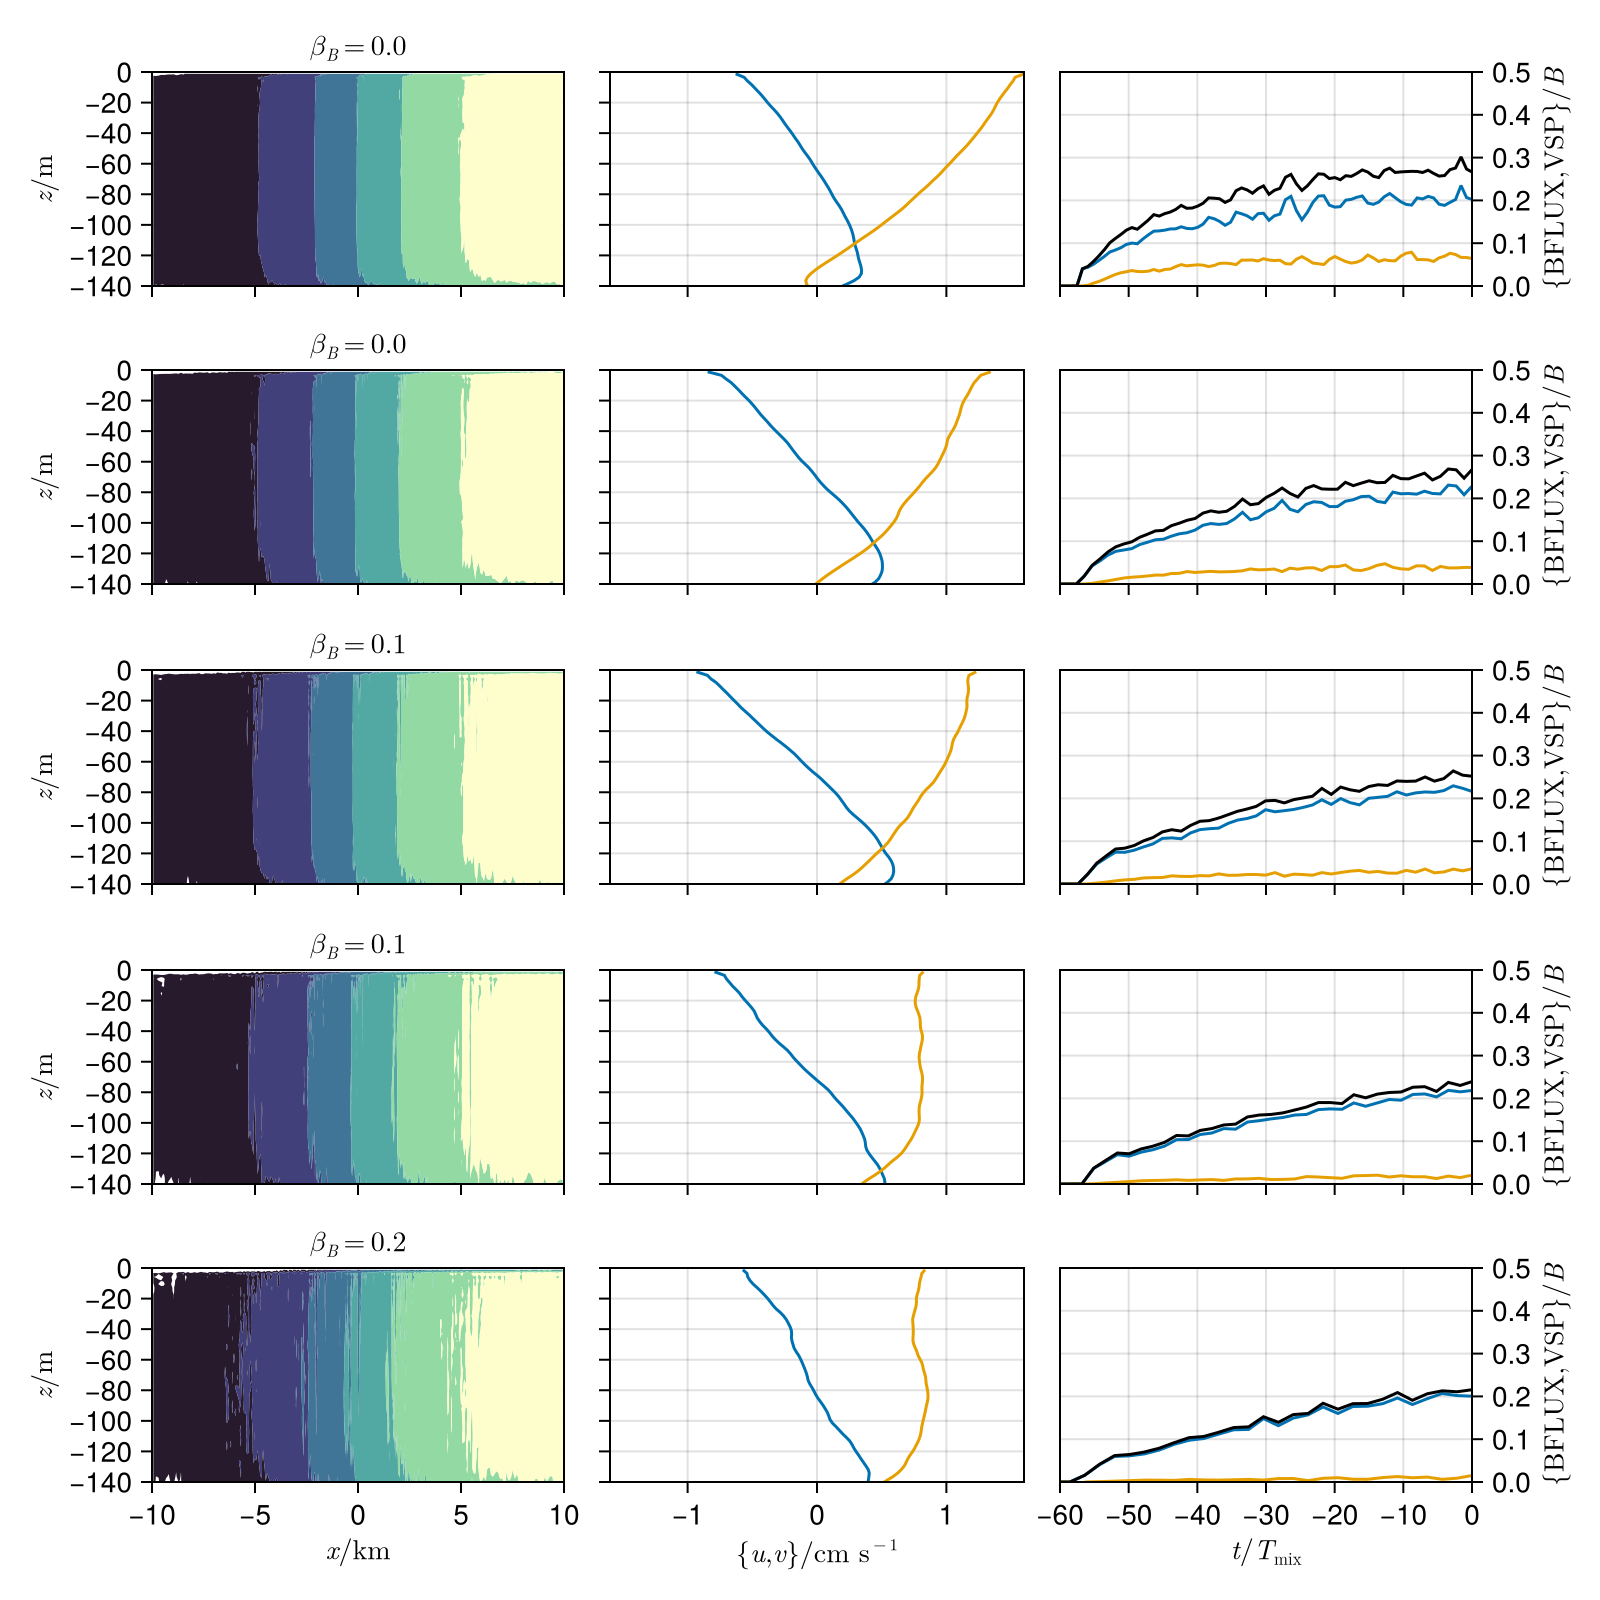

In [36]:
fig = Figure(; size=(800, 800))

for i in 1:n_runs
    DFM = joinpath(foldernames[i], "DFM.jld2")
    iterations, times = iterations_times(DFM)
    sp = simulation_parameters(DFM)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(DFM)
    inds = center_indices(DFM)
    
    
    βB = @sprintf "%02.1f" sp.βB
    ax = Axis(fig[i, 1];
        title = L"\beta_B = %$βB",
        xlabel = L"x / \text{km}",
        ylabel = L"z / \text{m}",
        limits = (-sp.Lx / 2000, sp.Lx / 2000, -sp.H, 0)
    )
    i < length(foldernames) && hidexdecorations!(ax; ticks=false)
    
    levels = (-0.5):(1 / 6):(0.5)
    colormap = reverse(to_colormap(:deep))

    ctf = contourf!(ax, xsᶜ ./ 1000, zsᶜ, (bs[i] .- mean(bs[i][:, end-3])) ./ sp.Δb; 
        colormap,
        levels,
        extendlow=:white
    )

    ax = Axis(fig[i, 2];
        xlabel = L"\{u, v\} / \text{cm}~\text{s}^{-1}",
        ylabel = L"z / \text{m}",
        limits = (-1.6, 1.6, -sp.H, 0)
    )
    i < length(foldernames) && hidexdecorations!(ax; ticks=false, grid=false)
    hideydecorations!(ax; ticks=false, grid=false)
    U = 0.01 #sp.L * sp.f
    lines!(ax, us[i] ./ U, zsᶜ)
    lines!(ax, vs[i] ./ U, zsᶜ)
    
    ax = Axis(fig[i, 3];
        xlabel = L"t/T_\text{mix}",
        ylabel = L"\{\text{BFLUX}, \text{VSP}\} / B",
        limits = (-60, 0, 0, 0.5),
        yaxisposition = :right
    )
    i < length(foldernames) && hidexdecorations!(ax; ticks=false, grid=false)
    
    BFLUX = BFLUXs[i] ./ sp.B
    VSP = VSPs[i] ./ sp.B
    
    lines!(ax, times ./ sp.T_mix, BFLUX)
    lines!(ax, times ./ sp.T_mix, VSP)
    lines!(ax, times ./ sp.T_mix, BFLUX .+ VSP; color=:black)

    #subfig_label!(fig[i, 1], 3*(i-1) + 1)
    #subfig_label!(fig[i, 2], 3*(i-1) + 2)
    #subfig_label!(fig[i, 3], 3*(i-1) + 3)
end
#save("initialized-fronts.png", fig; px_per_unit=2)
#save("initialized-fronts.svg", fig)
fig